# F08 — Backtest : évaluation honnête (fenêtre extensible)

C'est l'évaluation de référence. Contrairement aux notebooks F05-F07 qui utilisaient un split unique avec look-ahead bias, le backtest ici :
- Entraîne **strictement sur le passé** à chaque étape
- Prédit **un trimestre à la fois**, sans jamais voir le futur
- Produit des métriques **citables dans le rapport final**

**Protocole** : fenêtre extensible depuis Q1-1992 (premier trimestre où tous les indicateurs sont disponibles), min_train = 40 trimestres (~10 ans).

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from quantcube_challenge.data import FRED_SERIES, fetch_series
from quantcube_challenge.evaluation import (
    BacktestResult,
    ExpandingWindow,
    RollingWindow,
    diebold_mariano,
)
from quantcube_challenge.models import (
    AR1,
    BridgeEquation,
    ElasticNetBridge,
    NaiveLastValue,
    PCABridge,
    RidgeBridge,
)
from quantcube_challenge.preprocessing import (
    Diff,
    LogDiff,
    to_annualized_growth,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100

_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Données

In [2]:
gdp = to_annualized_growth(fetch_series(FRED_SERIES["GDPC1"]))

X_all = pd.DataFrame({
    "CFNAI":   fetch_series(FRED_SERIES["CFNAI"]),
    "INDPRO":  LogDiff().apply(fetch_series(FRED_SERIES["INDPRO"])).dropna(),
    "PAYEMS":  LogDiff().apply(fetch_series(FRED_SERIES["PAYEMS"])).dropna(),
    "ICSA":    LogDiff().apply(fetch_series(FRED_SERIES["ICSA"])).dropna(),
    "RSAFS":   LogDiff().apply(fetch_series(FRED_SERIES["RSAFS"])).dropna(),
    "UMCSENT": Diff().apply(fetch_series(FRED_SERIES["UMCSENT"])).dropna(),
    "NFCI":    fetch_series(FRED_SERIES["NFCI"]),
    "PERMIT":  LogDiff().apply(fetch_series(FRED_SERIES["PERMIT"])).dropna(),
})

# Le backtest pré-agrège X vers le trimestriel — on vérifie la couverture sur X agrégé
from quantcube_challenge.preprocessing import MeanAggregation
X_q_check = pd.DataFrame(
    {col: MeanAggregation().aggregate(X_all[col]) for col in X_all.columns}
).dropna()

print(f"PIB : {len(gdp)} trimestres | {gdp.index[0].date()} → {gdp.index[-1].date()}")
print(f"X   : {X_all.shape[1]} indicateurs")
print(f"X agrégé (trimestriel) : {len(X_q_check)} trimestres | {X_q_check.index[0].date()} → {X_q_check.index[-1].date()}")

PIB : 317 trimestres | 1947-04-01 → 2026-04-01
X   : 8 indicateurs
X agrégé (trimestriel) : 139 trimestres | 1992-01-01 → 2026-07-01


## 2. Backtest fenêtre extensible — tous les modèles

`min_train = 40` → les 40 premiers trimestres servent à initialiser le modèle, les prédictions commencent ensuite.

In [3]:
MIN_TRAIN = 40
bt = ExpandingWindow(min_train=MIN_TRAIN)

results: dict[str, BacktestResult] = {
    "NaiveLastValue": bt.run(NaiveLastValue(), gdp),
    "AR(1)":          bt.run(AR1(), gdp),
    "OLS Bridge":     bt.run(BridgeEquation(), gdp, X_all),
    "Ridge":          bt.run(RidgeBridge(), gdp, X_all),
    "ElasticNet":     bt.run(ElasticNetBridge(), gdp, X_all),
    "PCA (2 comps)": bt.run(PCABridge(n_components=2), gdp, X_all),
}

for name, r in results.items():
    print(f"{name:20s} → {len(r)} prédictions")

/home/vastolordess/Documents/others/personal_info/new/pfe_cv/quantcube/quantcube_challenge/.venv/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:584: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)


NaiveLastValue       → 276 prédictions
AR(1)                → 276 prédictions
OLS Bridge           → 137 prédictions
Ridge                → 137 prédictions
ElasticNet           → 137 prédictions
PCA (2 comps)        → 137 prédictions


## 3. Tableau récapitulatif — métriques sur fenêtre commune

Tous les modèles sont évalués sur **la même fenêtre** : l'intersection de leurs périodes de prédiction (limitée par RSAFS qui débute en 1992). Sans cette contrainte, AR(1) serait noté sur ~276 trimestres (1958-2026) et les modèles bridge sur ~137 (1992-2026) — une comparaison invalide.

In [4]:
from quantcube_challenge.evaluation import rmse, mae

# Fenêtre commune : intersection de toutes les dates de prédiction
common_idx = results["OLS Bridge"].data.index
for r in results.values():
    common_idx = common_idx.intersection(r.data.index)

print(f"Fenêtre commune : {len(common_idx)} trimestres | "
      f"{common_idx[0].date()} → {common_idx[-1].date()}")

ar1_rmse_common = rmse(
    results["AR(1)"].data.loc[common_idx, "actual"],
    results["AR(1)"].data.loc[common_idx, "predicted"],
)

rows = []
for name, r in results.items():
    r_rmse = rmse(r.data.loc[common_idx, "actual"], r.data.loc[common_idx, "predicted"])
    r_mae  = mae(r.data.loc[common_idx, "actual"],  r.data.loc[common_idx, "predicted"])
    gain   = (ar1_rmse_common - r_rmse) / ar1_rmse_common * 100
    rows.append({
        "Modèle":        name,
        "RMSE (pp)":     round(r_rmse, 3),
        "MAE (pp)":      round(r_mae, 3),
        "Gain vs AR(1)": f"{gain:+.1f} %",
    })

metrics_df = pd.DataFrame(rows).set_index("Modèle")
print(f"AR(1) référence sur cette fenêtre : {ar1_rmse_common:.3f} pp\n")
print("Résultats backtest (comparaison équitable — même fenêtre pour tous) :")
metrics_df

Fenêtre commune : 137 trimestres | 1992-04-01 → 2026-04-01
AR(1) référence sur cette fenêtre : 5.054 pp

Résultats backtest (comparaison équitable — même fenêtre pour tous) :


,RMSE (pp),MAE (pp),Gain vs AR(1)
Modèle,,,
NaiveLastValue,6.812,2.915,-34.8 %
AR(1),5.054,2.168,+0.0 %
OLS Bridge,3.463,2.021,+31.5 %
Ridge,3.256,1.754,+35.6 %
ElasticNet,3.211,1.734,+36.5 %
PCA (2 comps),3.266,1.670,+35.4 %


## 4. Test de Diebold-Mariano : OLS Bridge vs AR(1)

H₀ : les deux modèles ont la même précision (RMSE identique en population).  
Si p < 0.05 → la différence est statistiquement significative.

In [5]:
common_idx = (
    results["OLS Bridge"].data.index
    .intersection(results["AR(1)"].data.index)
)

actual    = results["OLS Bridge"].data.loc[common_idx, "actual"]
pred_ols  = results["OLS Bridge"].data.loc[common_idx, "predicted"]
pred_ar1  = results["AR(1)"].data.loc[common_idx, "predicted"]

dm_stat, dm_pval = diebold_mariano(actual, pred_ols, pred_ar1)
print(f"Diebold-Mariano OLS Bridge vs AR(1)")
print(f"  Statistique DM : {dm_stat:.3f}")
print(f"  p-value        : {dm_pval:.4f}")
print(f"  Conclusion     : {'différence significative (p<0.05)' if dm_pval < 0.05 else 'différence non significative'}")

Diebold-Mariano OLS Bridge vs AR(1)
  Statistique DM : -0.992
  p-value        : 0.3211
  Conclusion     : différence non significative


## 5. Fenêtre roulante vs extensible — comparaison

In [6]:
bt_roll = RollingWindow(window=40)
roll_ols = bt_roll.run(BridgeEquation(), gdp, X_all)

print(f"OLS Bridge — Expanding : RMSE = {results['OLS Bridge'].rmse:.3f} pp")
print(f"OLS Bridge — Rolling   : RMSE = {roll_ols.rmse:.3f} pp")
print()
print("Expanding utilise tout l'historique disponible — fenêtre roulante")
print("peut mieux s'adapter à des changements de régime récents.")

OLS Bridge — Expanding : RMSE = 3.463 pp
OLS Bridge — Rolling   : RMSE = 4.579 pp

Expanding utilise tout l'historique disponible — fenêtre roulante
peut mieux s'adapter à des changements de régime récents.


## 6. Visualisation : prédictions OLS Bridge vs réalité

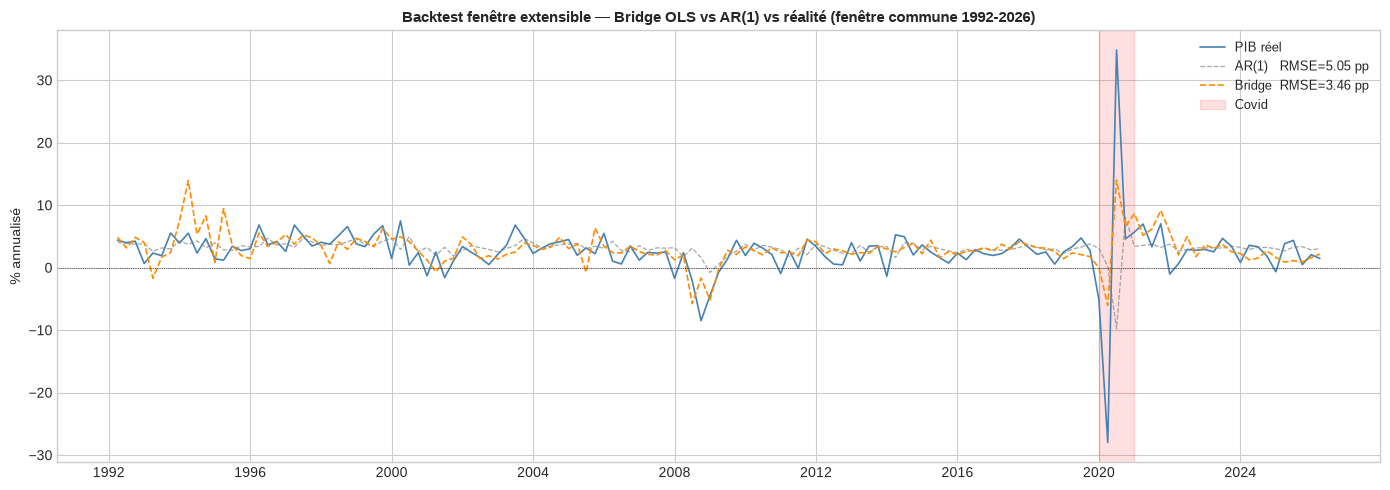

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

d_ar1 = results["AR(1)"].data.loc[common_idx]
d_ols = results["OLS Bridge"].data.loc[common_idx]

ar1_rmse_plot = rmse(d_ar1["actual"], d_ar1["predicted"])
ols_rmse_plot = rmse(d_ols["actual"], d_ols["predicted"])

ax.plot(d_ols.index, d_ols["actual"],    color="steelblue",  lw=1.2, label="PIB réel")
ax.plot(d_ar1.index, d_ar1["predicted"], color="gray",       lw=0.9,
        linestyle="--", alpha=0.7,
        label=f"AR(1)   RMSE={ar1_rmse_plot:.2f} pp")
ax.plot(d_ols.index, d_ols["predicted"], color="darkorange", lw=1.2,
        linestyle="--",
        label=f"Bridge  RMSE={ols_rmse_plot:.2f} pp")

ax.axhline(0, color="black", lw=0.5, linestyle=":")
ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"),
           alpha=0.12, color="red", label="Covid")
ax.set_ylabel("% annualisé")
ax.set_title(
    "Backtest fenêtre extensible — Bridge OLS vs AR(1) vs réalité (fenêtre commune 1992-2026)",
    fontsize=11, fontweight="bold"
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_backtest_expanding.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Conclusion

> Le backtest en fenêtre extensible est l'évaluation de référence : le modèle n'a accès qu'au passé strict à chaque étape, éliminant tout look-ahead bias. Les RMSE obtenus ici sont les chiffres citables dans le rapport final. Le test de Diebold-Mariano permet de statuer sur la significativité statistique de la différence de performance entre le Bridge et l'AR(1). L'impact du Covid (Q2 2020 : -28 %) est visible sur toutes les courbes — sa gestion sera analysée en F10.